# Introduction to basic models

In [1]:
import os
import dgl
import logging
import torch
import networkx as nx
import matplotlib.pyplot as plt
import random
import requests
from IPython.display import HTML
from IPython.display import Image
from IPython.display import Markdown, display

In [2]:
def get_code(raw_url, start_line=None, end_line=None):
    """
    Fetches raw code from a GitHub repository and returns a snippet of it with improved formatting.
    :param raw_url: The URL to the raw content of the file on GitHub.
    :param start_line: The starting line number (inclusive).
    :param end_line: The ending line number (inclusive).
    :return: The raw code snippet as a formatted string or an error message.
    """
    response = requests.get(raw_url)
    
    # Check if the request was successful
    if response.status_code != 200:
        return f"Failed to retrieve code. Status code: {response.status_code}. URL may be incorrect or redirected."
    
    # Check if we received HTML instead of raw text (indicating a redirect or wrong URL)
    if "<html>" in response.text.lower():
        return "Error: Received HTML content. Please check the URL, it might not be the raw file."
    
    # Split the response into lines and extract the snippet
    code_lines = response.text.splitlines()
    
    # Handle specific line range requests
    if start_line is None:
        start_line = 1
    if end_line is None:
        end_line = len(code_lines)
    
    # Adjust for 1-based indexing
    code_snippet = "\n".join(code_lines[start_line-1:end_line])
    
    # Return the formatted code snippet
    return code_snippet

<span style="font-size:20px; color:blue;">CLASS INHERITANCE EXPLAINED</span>


Classes are blueprints for creating objects

In [7]:
#Create a class 
class Students(): 
    pass

In [9]:
#create an instance of the class -- individual member of the class 
student_1 = Students()

The __init__() method -- also known as constructor or initializer -- receives 'self' as a default first argument, followed by other arguments. These arguments denote the content of class attributes. Defining an initializer is the first essential step when creating a class

In [12]:
class Students(): 
    def __init__(self, first, last, grade):
        self.first = first 
        self.last = last
        self.grade = grade
    def fullname(self):
        return (f'{self.first} {self.last}')
        

In [14]:
student_1 = Students("anna", "johnson", 76)

In [16]:
student_1.first

'anna'

In [18]:
student_1.fullname()

'anna johnson'

**INHERITANCE** -- allows a class to inherit attributes and methods from a parent class -- useful because by creating subclassess
we can modify and override methods and attributes of parent class without modifying the parent class directly 


In [21]:
class HistoryStudents(Students): #creating a subclass of history students which is a subset of all the students 
    pass

In [23]:
student_2 = HistoryStudents("martha", "wilde", 82) 

In [25]:
student_2.fullname()

'martha wilde'

We can see how the class HistoryStudents automatically inherited attributes first, last and grade and the method fullname() from the parent class

Now, let's see how inheritance works by modifying the fullname() method 

In [29]:
class HistoryStudents(Students):
    def __init__(self, first, last, grade):
        super().__init__(first, last, grade)
    def fullname(self): 
        return (f'{self.last} {self.first}') #changing fullname method to display surname first
                                            #we can call self.last and self.first 
                                            #without defining them in the initializer thanks to inheritance!

In [31]:
student_1.fullname()

'anna johnson'

In [33]:
student_1 = HistoryStudents("anna", "johnson", 76)

In [35]:
student_1.fullname()

'johnson anna'

<span style="font-size:22px; color:blue;">POLYGRAPHS CODE STRUCTURE</span>

Polygraphs operations are used to specify nodes and edges attributes. They are derived from the basic class PolygraphsOp and divided into common operations and complex operations 

**Common operations** include: BalaGoyalOp and OConnorandWeatherhallOp  

**Complex operations** include: GullibleBinomialOp, GullibleNegativeEps, AlignedBinomialOp, AlignedNegativeEpsOp

All Polygraphs operations follow the same logic: 

<img src="images/img2.png" alt="Alt Text" width="300" height="300"/> 

1. Initialize --> **init()**
2. Experiment --> **experiment()**
3. Filter --> **filterfn()**
4. Send --> **messagefn()**
5. Reduce --> **reducefn()**
6. Update --> **applyfn()**

All polygraphs operations inherit from the base class **PolygraphOp** which can be found in the ops.core.py module

In [42]:
snippet = get_code("https://raw.githubusercontent.com/alexandroskoliousis/polygraphs/main/polygraphs/ops/core.py", start_line = 11, end_line = 15)
display(Markdown(f'```python\n{snippet}\n```'))

```python
class PolyGraphOp(torch.nn.Module, metaclass=abc.ABCMeta):
    """
    Base operator from which all other operators are derived.
    """

```

The bulk of the __init__ and **experiment()** method are defined in the PolygraphOp

In [45]:
snippet = get_code("https://raw.githubusercontent.com/alexandroskoliousis/polygraphs/main/polygraphs/ops/core.py", start_line = 16, end_line = 42)
display(Markdown(f'```python\n{snippet}\n```'))

```python
    def __init__(self, graph, params):
        super().__init__()

        # Set device for experimentation
        self._device = params.device

        # The shape of all node attributes
        size = (graph.num_nodes(),)

        # Node beliefs that action B is better
        graph.ndata["beliefs"] = init.init(size, params.init).to(device=self._device)

        # Action B yields Bernoulli payoff of 1 (success) with probability p (= 0.5 + e)
        probs = init.halfs(size) + params.epsilon

        # Number of Bernoulli trials
        count = init.zeros(size) + params.trials

        # Each node gets a private signal that provides information
        # about whether action B is indeed a good action
        self._sampler = torch.distributions.binomial.Binomial(
            total_count=count, probs=probs
        )

        # Store action B's probability of success as a graph node attribute
        graph.ndata["logits"] = self._sampler.logits.to(device=self._device)

```

In [47]:
snippet = get_code("https://raw.githubusercontent.com/alexandroskoliousis/polygraphs/main/polygraphs/ops/core.py", start_line = 43, end_line = 48)
display(Markdown(f'```python\n{snippet}\n```'))

```python
    def sample(self):
        """
        Draws a sample from the binomial distribution.
        """
        return self._sampler.sample()

```

In [49]:
snippet = get_code("https://raw.githubusercontent.com/alexandroskoliousis/polygraphs/main/polygraphs/ops/core.py", start_line = 55, end_line = 70)
display(Markdown(f'```python\n{snippet}\n```'))

```python
    def experiment(self, graph):
        """
        Simulates an "experiment", where nodes who believe action B is better independently
        observe the payoffs from following action B by sampling a binomial distribution.
        """
        # Consider only nodes who believe action B is better
        mask = graph.ndata["beliefs"] > 0.5
        # Repeat mask
        mask = mask.tile((2, 1))
        # Sample distribution (a node observes only a few successful trials out of all trials)
        result = torch.stack((self.sample(), self.trials())).to(device=self._device)
        # Apply mask
        result = result * mask
        # Store per-node payoffs as a graph node attribute
        graph.ndata["payoffs"] = result.T

```

<span style="font-size:18px; color:black;"> **RELIABLE NETWORKS**</span>

Reliable networks follow a **BalaGoyalOp** which is defined as a subclass of PolygraphOp and therefore inherits the baseclass methods and attributes








In [53]:
snippet = get_code("https://raw.githubusercontent.com/alexandroskoliousis/polygraphs/main/polygraphs/ops/common.py", start_line = 40, end_line = 44)
display(Markdown(f'```python\n{snippet}\n```'))

```python
class BalaGoyalOp(core.PolyGraphOp):
    """
    Learning from neighbours (Bala & Goyal, 1998)
    """

```

Some reliable networks follow the **OConnorandWeaterhallOp**, which is defined as a subclass of BalaGoyalOp  

OConnorandWeaterhallOp modifies <span style="font-size:15x; color:purple;">____INIT()____ </span> by adding two parameters: **MISTRUST** and **ANTIUPDATING** 

In [56]:
snippet = get_code("https://raw.githubusercontent.com/alexandroskoliousis/polygraphs/main/polygraphs/ops/common.py", start_line = 105, end_line = 113)
display(Markdown(f'```python\n{snippet}\n```'))

```python
    def __init__(self, graph, params):
        super().__init__(graph, params)

        # Multiplier that captures how quickly agents become uncertain about
        # the evidence of their peers as their beliefs diverge.
        self.mistrust = params.mistrust

        # Whether to discount evidence with unti-updating or not
        self.antiupdating = params.antiupdating
```

Additionaly, it modifies <span style="font-size:15x; color:purple;">____REDUCE()____ </span> by adding a parameter, delta, specifying the distance between an agent's belief and its i-th neigbor belief

In [59]:
snippet = get_code("https://raw.githubusercontent.com/alexandroskoliousis/polygraphs/main/polygraphs/ops/common.py", start_line = 166, end_line = 166)
display(Markdown(f'```python\n{snippet}\n```'))

```python
                delta = torch.abs(prior - nodes.mailbox["beliefs"][:, i])
```

Then, depending on wether antiupdating is set or not, the function computes **certainty**, i.e. the belief that evidence provided by i-th neighbor is real, differently:

In [61]:
snippet = get_code("https://raw.githubusercontent.com/alexandroskoliousis/polygraphs/main/polygraphs/ops/common.py", start_line = 146, end_line = 190)
display(Markdown(f'```python\n{snippet}\n```'))

```python
        def function(nodes):
            # Log probability of successful trials
            logits = nodes.data["logits"]
            # Prior, P(H) (aka. belief)
            prior = nodes.data["beliefs"]

            # Number of nodes and number of neighbours per node (incoming messages)
            _, neighbours = nodes.mailbox["beliefs"].shape
            for i in range(neighbours):
                # A node receives evidence E from its i-th neighbour, say Jill,
                # denoting the number of successful trials and the total number
                # of trials she observed
                values = nodes.mailbox["payoffs"][:, i, 0]
                trials = nodes.mailbox["payoffs"][:, i, 1]

                # Evidence, E
                evidence = math.Evidence(logits, values, trials)

                # The difference in belief between an agent
                # and its i-th neighbour
                delta = torch.abs(prior - nodes.mailbox["beliefs"][:, i])

                # Compute belief that the evidence E is real, P(E)(d)
                if self.antiupdating:
                    certainty = torch.max(
                        1.0
                        - self._distancefn(delta)
                        * (1.0 - math.marginal(prior, evidence)),
                        torch.zeros((len(nodes),)),
                    )
                else:
                    # Consider an agent u and one of its neighbours, v. As
                    # beliefs between u and v diverge (delta towards 1),
                    # agent u simply ignores the evidence of agent v.
                    #
                    # If delta becomes 1, uncertainty ~ marginal. In other
                    # words, agent u's belief remains unchanged in light of
                    # agent v's evidence.
                    #
                    # The multiplier simply determines how far apart beliefs
                    # have to become before agent u begins to ignore the
                    # evidence of its neighbour, v (since delta never becomes 1)
                    certainty = 1.0 - torch.min(
                        torch.ones((len(nodes),)), self._distancefn(delta)
                    ) * (1.0 - math.marginal(prior, evidence))
```

Lastly, this operation uses **Jeffrey's rule** to update agents beliefs

In [65]:
snippet = get_code("https://raw.githubusercontent.com/alexandroskoliousis/polygraphs/main/polygraphs/ops/common.py", start_line = 192, end_line = 196)
display(Markdown(f'```python\n{snippet}\n```'))

```python
                # Compute posterior belief, in light of soft uncertainty
                posterior = math.jeffrey(prior, evidence, certainty)

                # Consider next neighbour
                prior = posterior
```

<span style="font-size:18px; color:black;"> **UNRELIABLE NETWORKS**</span>

Unreliable Network follow an **Unreliable Op** which inherits from the BalaGoyalOp and modifies some aspects of it. 

It modifies <span style="font-size:15x; color:purple;">____INIT()____ </span> by adding a **RELIABILITY** parameter

In [71]:
snippet = get_code("https://raw.githubusercontent.com/alexandroskoliousis/polygraphs/main/polygraphs/ops/complex.py", start_line = 30, end_line = 44)
display(Markdown(f'```python\n{snippet}\n```'))

```python
        # Store the reliability parameter
        self._network_reliability = params.reliability

        # Configure network reliability
        # Draw binary numbers from a Bernoulli distribution
        # (1s denote reliable nodes)
        self._reliability = torch.bernoulli(torch.ones(self._size) * params.reliability)

        # Given a list of unreliable nodes, make them unreliable
        for node in params.unreliablenodes:
            self._reliability[node] = 0

        # Store network reliability
        graph.ndata["reliability"] = self._reliability.to(device=self._device)

```

It modifies <span style="font-size:15x; color:purple;">____SAMPLE()____ </span> by adding an **Unreliable Sampler** parameter

In [74]:
snippet = get_code("https://raw.githubusercontent.com/alexandroskoliousis/polygraphs/main/polygraphs/ops/complex.py", start_line = 49, end_line = 61)
display(Markdown(f'```python\n{snippet}\n```'))

```python
    def sample(self):
        """
        Draws a sample from a reliable and unreliable sample
        for reliable and unreliable nodes
        """
        # pylint: disable=invalid-name
        # Sample reliable distribution
        b = self._sampler.sample()
        # Sample unreliable distribution
        u = self._unreliable_sampler.sample()
        # Combine samples
        return b * self._reliability + u * (1 - self._reliability)

```

Unreliable ops are divided 4 ways, based on wether:
1. The distribution from which the unreliable sampler is drawn is...:
  
     A) Binomial based on P(B) = 0.5  
 
     B) Binomial based on P(B) = 0.5 - ε


2. Wether agents are fully trusting of the received evidence

    A) Yes. Agents are **gullible** 

    B) No. Agents are **aligned**: they trust the evidence to a level that matches reliability, e.g. if reliability = 0.75, each egent trusts the evidence 75% of the way

 <span style="font-size:15x; color:purple;">____Possible combinations____ </span>:

1AA =  <span style="font-size:15x; color:purple;">GullibleBinomialOp </span>

1AB = <span style="font-size:15x; color:purple;">AlignedBinomialOp </span>

1BA = <span style="font-size:15x; color:purple;">GullibleNegEpsOp </span>

1BB = <span style="font-size:15x; color:purple;">AlignedNegEpsOp </span>

Gullible operations (1AA and 1BA) only modify INIT() by specifying the content of the unreliable sampler 

For **GullibleBinomialOP**:

In [80]:
snippet = get_code("https://raw.githubusercontent.com/alexandroskoliousis/polygraphs/main/polygraphs/ops/complex.py", start_line = 110, end_line = 124)
display(Markdown(f'```python\n{snippet}\n```'))

```python
    def __init__(self, graph, params):
        super().__init__(graph, params)
        # Unreliable Binomial Sampler:
        # Payoff: p = 0.5, epsilon = 0
        probs = init.halfs(self._size)

        # Number of Bernoulli trials
        count = init.zeros(self._size) + params.trials

        # Each node gets a private signal that provides information
        # about whether action B is indeed a good action
        self._unreliable_sampler = torch.distributions.binomial.Binomial(
            total_count=count, probs=probs
        )

```

For **GullibleNegEpsOp**:

In [83]:
snippet = get_code("https://raw.githubusercontent.com/alexandroskoliousis/polygraphs/main/polygraphs/ops/complex.py", start_line = 132, end_line = 145)
display(Markdown(f'```python\n{snippet}\n```'))

```python
    def __init__(self, graph, params):
        super().__init__(graph, params)
        # Unreliable Binomial Sampler with a negative epsilon
        probs = init.halfs(self._size) - params.epsilon

        # Number of Bernoulli trials
        count = init.zeros(self._size) + params.trials

        # Each node gets a private signal that provides information
        # about whether action B is indeed a good action
        self._unreliable_sampler = torch.distributions.binomial.Binomial(
            total_count=count, probs=probs
        )

```

**Aligned ops** modify the reduce function (why not the apply func?) and use Jeffreys rule 

In [86]:
snippet = get_code("https://raw.githubusercontent.com/alexandroskoliousis/polygraphs/main/polygraphs/ops/complex.py", start_line = 180, end_line = 219)
display(Markdown(f'```python\n{snippet}\n```'))

```python
    def reducefn(self):
        """
        Reduce function
        """

        def function(nodes):
            # Log probability of successful trials
            logits = nodes.data["logits"]
            # Prior, P(H) (aka. belief)
            prior = nodes.data["beliefs"]

            # Number of nodes and number of neighbours per node (incoming messages)
            _, neighbours = nodes.mailbox["reliability"].shape
            for i in range(neighbours):
                # A node receives evidence E from its i-th neighbour, say Jill,
                # denoting the number of successful trials and the total number
                # of trials she observed
                values = nodes.mailbox["payoffs"][:, i, 0]
                trials = nodes.mailbox["payoffs"][:, i, 1]

                # Evidence, E
                evidence = math.Evidence(logits, values, trials)

                # Get i-th neighbour reliability
                reliability = nodes.mailbox["reliability"][:, i]

                # log.info(f"Neighbour {i:2d}: reliability {reliability}")

                # Compute posterior belief, in light of soft uncertainty
                # (i.e., network unreliability)
                posterior = math.jeffrey(prior, evidence, reliability)

                # Consider next neighbour
                prior = posterior

            # Return posterior beliefs for each neighbour
            return {"beliefs": posterior}

        return function

```

## Run simulations

Polygraphs allows us to run simulations on different networks with different parameters 

<span style="font-size:17px; color:blue;"> BASIC CONFIGURATIONS</span>

Here is a list of some default configuration values for our simulations. 


<span style="font-size:15px; color:purple;">**op**</span> : ops. BalaGoyalOp, ops.UnreliableNetworkBasicGullibleBinomialOp, ops.UnreliableNetworkBasicGullibleNegativeEpsOp, ops.UnreliableNetworkBasicAlignedBinomialOp, ops.UnreliableNetworkBasicAlignedNegativeEpsOp, ops.OConnorWeatherallOp

<span style="font-size:15px; color:purple;">**params.network.kind**</span> : 'complete', 'star', 'cycle', 'karate', 'barabasialbert', 'wattsstrogatz', 'random' 

<span style="font-size:15px; color:purple;">**params.network.size**</span> : 16, 32, 64

<span style="font-size:15px; color:purple;">**params.epsilon**</span> : 0.01, 0.001

<span style="font-size:15px; color:purple;">**params.reliability**</span> : 0.75, 0.50, 0.25


Additionally...

If you selected **BARABASIALBERT** as network.kind 

<span style="font-size:15px; color:purple;">**params.network.barabasialbert.attachments**</span> : 1, 2, 4, 8, 16, 24, 32

If you selected **WATTSSTROGATZ** as network.kind

<span style="font-size:15px; color:purple;">**params.network.wattsstrogatz.knn**</span> : 1, 2, 4, 8, 16, 32

<span style="font-size:15px; color:purple;">**params.network.wattsstrogatz.probability**</span> : 0, 0.2, 0.25, 0.4, 0.5, 0.75, 0.8, 1

If you selected **RANDOM** as network.kind

<span style="font-size:15px; color:purple;">**params.network.random.probability**</span> : 0.03, 0.06, 0.12, 0.24, 0.38, 0.51

Here is 64 node random network with a rewiring probability of 0.06

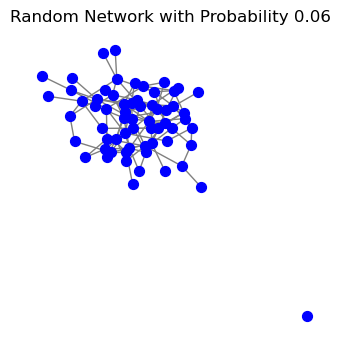

In [17]:
# Parameters
num_nodes = 64  # Number of nodes in the network
rewire_prob = 0.06  # Probability of edge creation


# Generate a random graph using the Erdős-Rényi model
random_network = nx.erdos_renyi_graph(num_nodes, rewire_prob)

# Draw the network
plt.figure(figsize=(3, 3))
nx.draw(random_network, node_size=50, with_labels=False, node_color="blue", edge_color="gray")
plt.title("Random Network with Probability 0.06")
plt.show()
random_network = nx.erdos_renyi_graph(num_nodes, rewire_prob)

In [91]:
#import relevant modules
import polygraphs as pg

from polygraphs import hyperparameters as hparams
from polygraphs import ops

In [102]:
# Create a PolyGraph configuration
params = hparams.PolyGraphHyperParameters()

# Initial beliefs are random uniform between 0 and 1
params.init.kind = 'uniform'
# Chance that action B is better than action A
params.epsilon = 0.01
# Kind and size of network (a complete network with 10 agents)
params.network.kind = 'complete'
params.network.size = 16

# Enable logging; print progress every 100 steps
params.logging.enabled = True
params.logging.interval = 100

# Run 1,000 steps per simulation; repeat simulation 10 times
params.simulation.steps = 1000
params.simulation.repeats = 10

params.antiupdating = True
params.mistrust = 1

# Set seed
params.seed = 123456789

pg.random(params.seed)
_ = pg.simulate(params, op=ops.OConnorWeatherallOp)

print('Bye.')

[MON] step 0001 Ksteps/s   0.00 A/B 0.56/0.44
[MON] step 0099 Ksteps/s   0.16 A/B 0.00/1.00
 INFO polygraphs> Sim #0001:     99 steps    0.62s; action: B undefined: 0 converged: 1 polarized: 0 
[MON] step 0001 Ksteps/s   0.00 A/B 0.75/0.25
[MON] step 0100 Ksteps/s   0.17 A/B 0.00/1.00
[MON] step 0129 Ksteps/s   0.16 A/B 0.00/1.00
 INFO polygraphs> Sim #0002:    129 steps    0.79s; action: B undefined: 0 converged: 1 polarized: 0 
[MON] step 0001 Ksteps/s   0.00 A/B 0.44/0.56
[MON] step 0100 Ksteps/s   0.17 A/B 0.06/0.94
[MON] step 0154 Ksteps/s   0.16 A/B 0.00/1.00
 INFO polygraphs> Sim #0003:    154 steps    0.97s; action: B undefined: 0 converged: 1 polarized: 0 
[MON] step 0001 Ksteps/s   0.00 A/B 0.38/0.62
[MON] step 0100 Ksteps/s   0.17 A/B 0.06/0.94
[MON] step 0200 Ksteps/s   0.16 A/B 0.12/0.88
[MON] step 0233 Ksteps/s   0.16 A/B 0.00/1.00
 INFO polygraphs> Sim #0004:    233 steps    1.45s; action: B undefined: 0 converged: 1 polarized: 0 
[MON] step 0001 Ksteps/s   0.00 A/B 0.62

<span style="font-size:17px; color:red;">TRY IT OUT! 

Now it's your turn. Run a simulation on a network of **size 32** with the **AlignedBinomial Op**. You can select your preferred network. kind alongside the other parameters

## Write a new custom operation

<span style="font-size:17px; color:red;">TRY IT OUT! 

How would you write a new operation? Assuming that you want to write an operation that introduces fact-checkers in the networks and influences node behavior in the following way:
- Nodes are divided in 3 groups: fact-checkers, misinformants, users (A) (+)
- If a fact-checker is part of a triangle fact-checker-misinformant-user, the edge misinformant-user is deactivated (B) (+)
- Agents are fully trusting (C) 

**What class would you use as base-class?**

<span style="font-size:13px; color:blue;">REMINDER: our new fact-checkers class will inherit attribute and methods form the specified base-class. The goal is having to write as less code as possible

a) PolygraphsOp

b) BalaGoyalOp

c) UnreliableOp

d) UnreliableNetworkBasicGullibleUniformOp

e) UnreliableNetworkBasicGullibleNegEpsOp

f) UnreliableNetworkBasicAlignedBinomialOp

g) UnreliableNetworkBasicAlignedNegEpsOp

**Where would you need to modify the code to achieve A?**

a) init()
b) sample()
c) experiment()
d) filter()
e) apply()


**Where would you need to modify the code to achieve B?**

a) init()
b) sample()
c) experiment()
d) filter()
e) apply()

In [51]:
from polygraphs.ops.complex import UnreliableNetworkBasicGullibleBinomialOp

In [38]:
class FactCheckersOp(ops.complex.UnreliableNetworkBasicGullibleBinomialOp):
    """
  FactCheckers operator for moderating unreliable nodes.
    """

    def __init__(self, graph, params):
        # Call the base class's initializer first to set up everything needed
        super().__init__(graph, params)

        # Define the group labels (Fact-checkers, Unreliable, Users)
        self.group_labels = {0: "Fact-checkers", 1: "Unreliable", 2: "Users"}

        # Probabilities for group assignment: Fact-checkers (2), Unreliable (3), Users (7)
        weights = torch.tensor([1, 5, 7], dtype=torch.float)

        # Assign nodes to groups based on probabilities
        group_assignments = torch.multinomial(weights, graph.num_nodes(), replacement=True)

        # Assign the group data to nodes
        graph.ndata['group'] = group_assignments.to(self._device)

        # Set reliability: Fact-checkers (group 0) and Users (group 2) are reliable by default
        reliability = torch.ones(graph.num_nodes(), dtype=torch.float)
        reliability[group_assignments == 1] = 0  # Unreliable nodes (group 1) get reliability of 0

        # Now assign the reliability to the graph
        graph.ndata["reliability"] = reliability.to(params.device)

        # Count the number of nodes in each group
        fact_checkers_count = torch.sum(group_assignments == 0).item()
        unreliable_count = torch.sum(group_assignments == 1).item()
        users_count = torch.sum(group_assignments == 2).item()

        # Print out the counts
        print(f"Number of Fact-checkers: {fact_checkers_count}")
        print(f"Number of Unreliable nodes: {unreliable_count}")
        print(f"Number of Users: {users_count}")


    def filterfn(self):
        """Filters out edges between Unreliable and Users when a Fact-checker is connected to the Unreliable node."""
        def function(edges):
            src_group = edges.src['group']
            dst_group = edges.dst['group']

            # Fact-checkers (group 0), Unreliable (group 1), Users (group 2)
            fact_checker_group = 0
            misinformant_group = 1
            user_group = 2

            # Determine if a fact-checker is connected to the Unreliable node (src or dst)
            fact_checker_connected_to_misinformant = (
                (src_group == fact_checker_group) & (dst_group == misinformant_group)) | \
                ((src_group == misinformant_group) & (dst_group == fact_checker_group))

            # Determine if an edge is between an Unreliable node and a User
            misinformant_user_edge = ((src_group == misinformant_group) & (dst_group == user_group)) | \
                                     ((src_group == user_group) & (dst_group == misinformant_group))

            # Determine if an edge is between a User and Fact-checker
            fact_checker_user_edge = ((src_group == fact_checker_group) & (dst_group == user_group)) | \
                                     ((src_group == user_group) & (dst_group == fact_checker_group))

            # Block edges between Unreliable and Users when a Fact-checker is connected to the Unreliable node
            block_edge = misinformant_user_edge & fact_checker_connected_to_misinformant

            # Allow all other edges
            allow_edge = ~block_edge

            return allow_edge

        return function

Run simulations on new operation

In [ ]:
# Create a PolyGraph configuration
params = hparams.PolyGraphHyperParameters()

# Initial beliefs are random uniform between 0 and 1
params.init.kind = 'uniform'
# Chance that action B is better than action A
params.epsilon = 0.01
# Kind and size of network (a complete network with 10 agents)
params.network.kind = 'star'
params.network.size = 32

# Enable logging; print progress every 100 steps
params.logging.enabled = True
params.logging.interval = 100
params.mistrust = 1.5

# Run 1,000 steps per simulation; repeat simulation 10 times
params.simulation.steps = 1000
params.simulation.repeats = 3

pg.random(params.seed)

# Run simulation
_ = pg.simulate(params, op=FactCheckersOp) #insert the new operation

print('Bye.')